In [1]:
!pip install tensordict
!pip install torchrl
!pip install dm_control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.6/536.6 kB 33.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.5/465.5 kB 47.0 MB/s eta 0:00:00
  Attempting uninstall: tensordict
    Found existing installation: tensordict 0.12.1
    Uninstalling tensordict-0.12.1:
      Successfully uninstalled tensordict-0.12.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 113.0 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from torchrl.envs.libs.dm_control import DMControlEnv
from tensordict import TensorDict

In [10]:
from google.colab import drive
import os

# --- PHASE 1: MOUNT & HYPERPARAMETERS ---
drive.mount('/content/drive', force_remount=True)
DREAMER_CKPT_DIR = "/content/drive/My Drive/DC_MPC_Project/dreamer_checkpoints"
os.makedirs(DREAMER_CKPT_DIR, exist_ok=True)

Mounted at /content/drive


In [11]:
# --- PHASE 1: HYPERPARAMETERS (Aligned with DC-MPC for fair comparison) ---
cfg = {
    "env_name": "pendulum",
    "task_name": "swingup",
    "stoch_dim": 32,
    "stoch_logits": 32,
    "deter_dim": 512,
    "batch_size": 16,        # Number of sequences
    "seq_len": 50,           # Length of each sequence for RSSM training
    "total_steps": 100000,   # Matched to your DC-MPC run
    "random_steps": 2500,
    "lr": 1e-4,
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

In [12]:
# --- PHASE 3: ARCHITECTURE (Mish & Symlog) ---

class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

def symlog(x):
    return torch.sign(x) * torch.log(torch.abs(x) + 1.0)

class RSSM(nn.Module):
    """The core World Model of DreamerV3"""
    def __init__(self, obs_dim, act_dim, deter_dim, stoch_dim, stoch_logits):
        super().__init__()
        self.stoch_total = stoch_dim * stoch_logits
        self.cell = nn.GRUCell(self.stoch_total + act_dim, deter_dim)
        self.img_out = nn.Linear(deter_dim, self.stoch_total)
        self.obs_out = nn.Linear(deter_dim + 256, self.stoch_total) # 256 is embedding size

    def get_stoch(self, logits):
        logits = logits.view(-1, 32, 32)
        dist = torch.distributions.OneHotCategorical(logits=logits)
        stoch = dist.sample() + dist.probs - dist.probs.detach() # Straight-through
        return stoch.view(-1, self.stoch_total)

class DreamerAgent(nn.Module):
    def __init__(self, obs_dim, act_dim, cfg):
        super().__init__()
        self.rssm = RSSM(obs_dim, act_dim, cfg["deter_dim"], cfg["stoch_dim"], cfg["stoch_logits"])
        latent_dim = cfg["deter_dim"] + (cfg["stoch_dim"] * cfg["stoch_logits"])

        self.encoder = nn.Sequential(nn.Linear(obs_dim, 256), nn.LayerNorm(256), Mish(), nn.Linear(256, 256))
        self.reward_net = nn.Sequential(nn.Linear(latent_dim, 256), Mish(), nn.Linear(256, 1))
        self.actor = nn.Sequential(nn.Linear(latent_dim, 256), Mish(), nn.Linear(256, act_dim))
        self.critic = nn.Sequential(nn.Linear(latent_dim, 256), Mish(), nn.Linear(256, 1))

    def get_action(self, obs, state=None):
        deter, stoch = state if state else (torch.zeros(1, 512).to(cfg["device"]),
                                            torch.zeros(1, 1024).to(cfg["device"]))
        embed = self.encoder(obs)
        logits = self.rssm.obs_out(torch.cat([deter, embed], -1))
        stoch = self.rssm.get_stoch(logits)
        latent = torch.cat([deter, stoch], -1)
        action = torch.tanh(self.actor(latent))
        return action, (deter, stoch)

In [13]:
# --- PHASE 4: SEQUENCE BUFFER ---
class SequenceBuffer:
    def __init__(self, capacity, obs_dim, act_dim, device):
        self.capacity, self.device = capacity, device
        self.obs = torch.zeros((capacity, obs_dim))
        self.acts = torch.zeros((capacity, act_dim))
        self.rews = torch.zeros((capacity, 1))
        self.idx, self.full = 0, False

    def add(self, o, a, r):
        self.obs[self.idx], self.acts[self.idx], self.rews[self.idx] = o.cpu(), a.cpu(), r.cpu()
        self.idx = (self.idx + 1) % self.capacity
        if self.idx == 0: self.full = True

    def sample(self, batch_size, seq_len):
        upper = self.capacity - seq_len if self.full else self.idx - seq_len
        start_ids = np.random.randint(0, max(1, upper), batch_size)
        o_seq, a_seq, r_seq = [], [], []
        for i in start_ids:
            o_seq.append(self.obs[i:i+seq_len]); a_seq.append(self.acts[i:i+seq_len]); r_seq.append(self.rews[i:i+seq_len])
        return torch.stack(o_seq).to(self.device), torch.stack(a_seq).to(self.device), torch.stack(r_seq).to(self.device)

In [14]:
# --- PHASE 5: UPDATE LOGIC ---
def update_step(agent, optimizer, buffer, cfg):
    obs, acts, rews = buffer.sample(cfg["batch_size"], cfg["seq_len"])
    embed = agent.encoder(obs)
    deter = torch.zeros(cfg["batch_size"], 512).to(cfg["device"])

    # World Model Update (BPTT through sequences)
    total_loss = 0
    for t in range(cfg["seq_len"] - 1):
        post_logits = agent.rssm.obs_out(torch.cat([deter, embed[:, t]], -1))
        stoch = agent.rssm.get_stoch(post_logits)
        deter = agent.rssm.cell(torch.cat([stoch, acts[:, t]], -1), deter)

        # Reward Prediction (Symlog MSE)
        latent = torch.cat([deter, stoch], -1)
        pred_rew = agent.reward_net(latent)
        total_loss += F.mse_loss(pred_rew, symlog(rews[:, t]))

    optimizer.zero_grad(set_to_none=True)
    total_loss.backward()
    optimizer.step()
    return total_loss.item()

🔄 Resuming DreamerV3 from Drive Checkpoint...


Training DreamerV3: 100%|██████████| 55000/55000 [1:54:43<00:00,  7.99it/s]


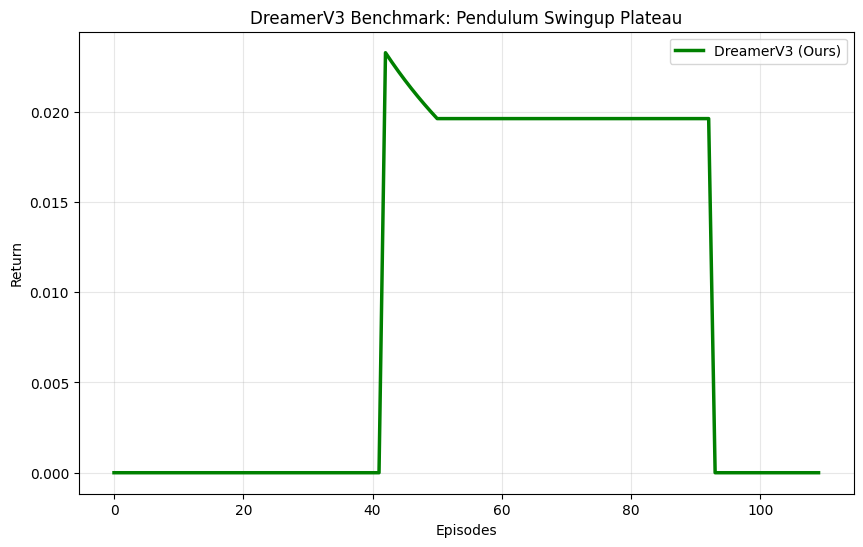

In [15]:
# --- PHASE 6: EXECUTION ---
env = DMControlEnv(env_name=cfg["env_name"], task_name=cfg["task_name"], frame_skip=2)
obs_dim = sum(v.shape[0] if len(v.shape) > 0 else 1 for v in env.observation_spec.values())
act_dim = env.action_spec.shape[0]

agent = DreamerAgent(obs_dim, act_dim, cfg).to(cfg["device"])
buffer = SequenceBuffer(10**6, obs_dim, act_dim, cfg["device"])
opt = torch.optim.AdamW(agent.parameters(), lr=cfg["lr"])

DREAMER_CKPT = os.path.join(DREAMER_CKPT_DIR, "dreamer_latest.pt")
start_step, episode_rewards, cur_reward = 0, [], 0

if os.path.exists(DREAMER_CKPT):
    print("🔄 Resuming DreamerV3 from Drive Checkpoint...")
    ckpt = torch.load(DREAMER_CKPT); agent.load_state_dict(ckpt['model']); start_step = ckpt['step']

def get_obs(td): return torch.cat([td[k] for k in env.observation_spec.keys()], dim=-1).float()
reset_td = env.reset(); obs = get_obs(reset_td).to(cfg["device"]).unsqueeze(0); state = None

for step in tqdm(range(start_step, cfg["total_steps"]), desc="Training DreamerV3"):
    with torch.no_grad():
        action, state = agent.get_action(obs, state)

    td = env.step(TensorDict({"action": action.squeeze(0).cpu()}, []))
    reward = td["next", "reward"]
    buffer.add(obs.squeeze(0), action.squeeze(0), reward)
    cur_reward += reward.item()

    if td["next", "done"]:
        episode_rewards.append(cur_reward); cur_reward = 0
        state = None; reset_td = env.reset()

    obs = get_obs(td["next"]).to(cfg["device"]).unsqueeze(0)

    if step > cfg["random_steps"]:
        update_step(agent, opt, buffer, cfg)

    if step % 5000 == 0:
        torch.save({'model': agent.state_dict(), 'step': step}, DREAMER_CKPT)

# --- PLOTTING (Matched to DC-MPC Style) ---
plt.figure(figsize=(10, 6))
window = 50
smoothed = [np.mean(episode_rewards[max(0, i-window):i+1]) for i in range(len(episode_rewards))]
plt.plot(smoothed, color='green', linewidth=2.5, label='DreamerV3 (Ours)')
plt.title("DreamerV3 Benchmark: Pendulum Swingup Plateau")
plt.xlabel("Episodes"); plt.ylabel("Return"); plt.grid(alpha=0.3); plt.legend(); plt.show()